# Emotions per framing category — significance testing

Tests whether **anger**, **fear**, and **sadness** in framing-hit context windows differ significantly from the corpus **macro-mean**, per outlet × framing category.

**Unit of analysis:** each row is a short context window around a media-criticism keyword (e.g. *Lügenpresse*, *Zensur*) that was classified by GPT into a framing category.

**Approach:** one-sample Wilcoxon signed-rank test against the macro-mean (average of per-outlet means, consistent with the topic-analysis heatmaps in `05a`/`05b`). This avoids the Tagesschau comparison problem: Tagesschau has only 5–31 non-neutral hits per category because it is the outlet *being criticised*, so it naturally appears far less. Comparing other outlets against Tagesschau would therefore be comparing against a near-empty reference group. The meaningful question is instead: "Does outlet X discuss framing category Y with significantly more/less anger than the *typical* outlet?"

Cells with **n < 10** are greyed out. Significance is BH-corrected at α = 0.05 across all valid (outlet × category × emotion) triples.

## 1  Load data

`emotion_mainstream_resultsv2.csv` already contains both framing category and emotion scores — no merge needed. Rows with `category == NEUTRAL` or `IRRELEVANT` are excluded from the significance test.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

root = Path.cwd()
if root.name == "04_SentimentAnalysis":
    root = root.parent

df = pd.read_csv(root / "04_SentimentAnalysis/outputs/emotion_mainstream_resultsv2.csv")

EMOTIONS  = ["emotion_anger", "emotion_fear", "emotion_sadness"]
SKIP_CATS = {"NEUTRAL", "IRRELEVANT"}
MIN_N     = 10

for col in EMOTIONS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["source", "category"] + EMOTIONS)
df = df[~df["category"].isin(SKIP_CATS)]

# macro-mean: average of per-outlet means (corrects for outlet size imbalance)
macro_mean = {
    em: float(df.groupby("source")[em].mean().mean())
    for em in EMOTIONS
}
overall_std = {
    em: float(df[em].std())
    for em in EMOTIONS
}

print("Rows after filtering:", len(df))
print("Categories:", sorted(df["category"].unique()))
print("Outlets:   ", sorted(df["source"].unique()))
print()
print("Macro-means:", {k: f"{v:.3f}" for k, v in macro_mean.items()})
print("Overall std:", {k: f"{v:.3f}" for k, v in overall_std.items()})
print()
print(df.groupby(["source", "category"]).size().unstack(fill_value=0).to_string())


Rows after filtering: 3192
Categories: ['DISINFORMATION/FALSCHDARSTELLUNG', 'POSITIONS-/PARTEILICHKEITS-BIAS', 'VERSAGEN/INKOMPETENZ', 'VERZERRUNG/MANIPULATION']
Outlets:    ['Antispiegel', 'Compact', 'Deutschlandkurier', 'Nius', 'RT_de', 'Tagesschau', 'Tichys_Einblick']

Macro-means: {'emotion_anger': '0.854', 'emotion_fear': '0.222', 'emotion_sadness': '0.280'}
Overall std: {'emotion_anger': '0.160', 'emotion_fear': '0.177', 'emotion_sadness': '0.186'}

category           DISINFORMATION/FALSCHDARSTELLUNG  POSITIONS-/PARTEILICHKEITS-BIAS  VERSAGEN/INKOMPETENZ  VERZERRUNG/MANIPULATION
source                                                                                                                             
Antispiegel                                      45                               75                    26                      163
Compact                                          34                               81                     9                       58
Deutschlandk

## 2  One-sample Wilcoxon signed-rank test + BH correction

For each *(framing category, emotion, outlet)* triple:
- Skip if **n < 10 observations**
- Shift cell values by the macro-mean and apply a two-sided Wilcoxon signed-rank test
- Effect size: standardised deviation from macro-mean = (cell mean − macro-mean) / overall σ
- Benjamini-Hochberg FDR correction at α = 0.05 across all valid (outlet × category × emotion) triples

In [2]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

outlets = sorted(df["source"].unique())
records, excluded = [], []

for emotion in EMOTIONS:
    mm  = macro_mean[emotion]
    std = overall_std[emotion]
    for cat in df["category"].unique():
        df_c = df[df["category"] == cat]
        for outlet in outlets:
            cell_vals = df_c.loc[df_c["source"] == outlet, emotion].values
            n = len(cell_vals)
            if n < MIN_N:
                excluded.append({"emotion": emotion, "category": cat, "outlet": outlet, "n": n})
                continue
            shifted = cell_vals - mm
            if np.all(shifted == 0):
                excluded.append({"emotion": emotion, "category": cat, "outlet": outlet, "n": n})
                continue
            try:
                stat, p_raw = wilcoxon(shifted, alternative="two-sided", zero_method="wilcox")
            except ValueError:
                excluded.append({"emotion": emotion, "category": cat, "outlet": outlet, "n": n})
                continue
            cell_mean = float(np.mean(cell_vals))
            records.append({
                "emotion":    emotion,
                "category":   cat,
                "outlet":     outlet,
                "n":          n,
                "mean":       cell_mean,
                "macro_mean": mm,
                "effect":     (cell_mean - mm) / std,
                "stat":       stat,
                "p_raw":      p_raw,
            })

results = pd.DataFrame(records)
if len(results):
    reject, p_adj, _, _ = multipletests(results["p_raw"].values, alpha=0.05, method="fdr_bh")
    results["p_adjusted"]  = p_adj
    results["significant"] = reject
    results = results.sort_values("p_adjusted").reset_index(drop=True)

print(f"Valid cells tested: {len(results)}  |  Excluded (n < {MIN_N}): {len(excluded)}")
print(f"Significant (p_adj < 0.05): {results['significant'].sum()}")
results.head(15)


Valid cells tested: 72  |  Excluded (n < 10): 12
Significant (p_adj < 0.05): 24


,emotion,category,outlet,n,mean,macro_mean,effect,stat,p_raw,p_adjusted,significant
0,emotion_anger,POSITIONS-/PARTEILICHKEITS-BIAS,Tichys_Einblick,594,0.873150,0.853943,0.120210,52037.0,3.961110e-18,2.851999e-16,True
1,emotion_anger,POSITIONS-/PARTEILICHKEITS-BIAS,Nius,362,0.868963,0.853943,0.094004,18897.0,2.488374e-12,8.958147e-11,True
2,emotion_anger,VERZERRUNG/MANIPULATION,Tichys_Einblick,373,0.874471,0.853943,0.128483,20600.0,7.339649e-12,1.761516e-10,True
3,emotion_anger,DISINFORMATION/FALSCHDARSTELLUNG,Tichys_Einblick,124,0.900197,0.853943,0.289495,1484.0,2.485897e-09,4.474615e-08,True
4,emotion_sadness,POSITIONS-/PARTEILICHKEITS-BIAS,Tichys_Einblick,594,0.259588,0.279661,-0.107987,64830.0,1.880823e-08,2.429406e-07,True
5,emotion_anger,VERZERRUNG/MANIPULATION,Nius,296,0.870220,0.853943,0.101873,13710.0,2.024505e-08,2.429406e-07,True
6,emotion_fear,VERZERRUNG/MANIPULATION,Antispiegel,163,0.171573,0.222088,-0.284974,3394.0,5.042889e-08,5.186971e-07,True
7,emotion_sadness,VERZERRUNG/MANIPULATION,Tichys_Einblick,373,0.252686,0.279661,-0.145118,24361.0,4.512519e-07,4.061267e-06,True
8,emotion_anger,DISINFORMATION/FALSCHDARSTELLUNG,Antispiegel,45,0.909001,0.853943,0.344601,115.0,9.275997e-07,7.420797e-06,True
9,emotion_fear,DISINFORMATION/FALSCHDARSTELLUNG,Tichys_Einblick,124,0.170450,0.222088,-0.291308,1950.0,1.584067e-06,1.140528e-05,True


## 3  Heatmaps per emotion

For each emotion: two heatmaps side-by-side —
- **Left:** mean score per framing category × outlet (diverging from corpus macro-mean; cells with n < MIN_N greyed out; `*` / `**` mark BH-significant cells)
- **Right:** standardised effect size = (cell mean − macro-mean) / overall σ (positive = outlet above macro-mean in that framing context)

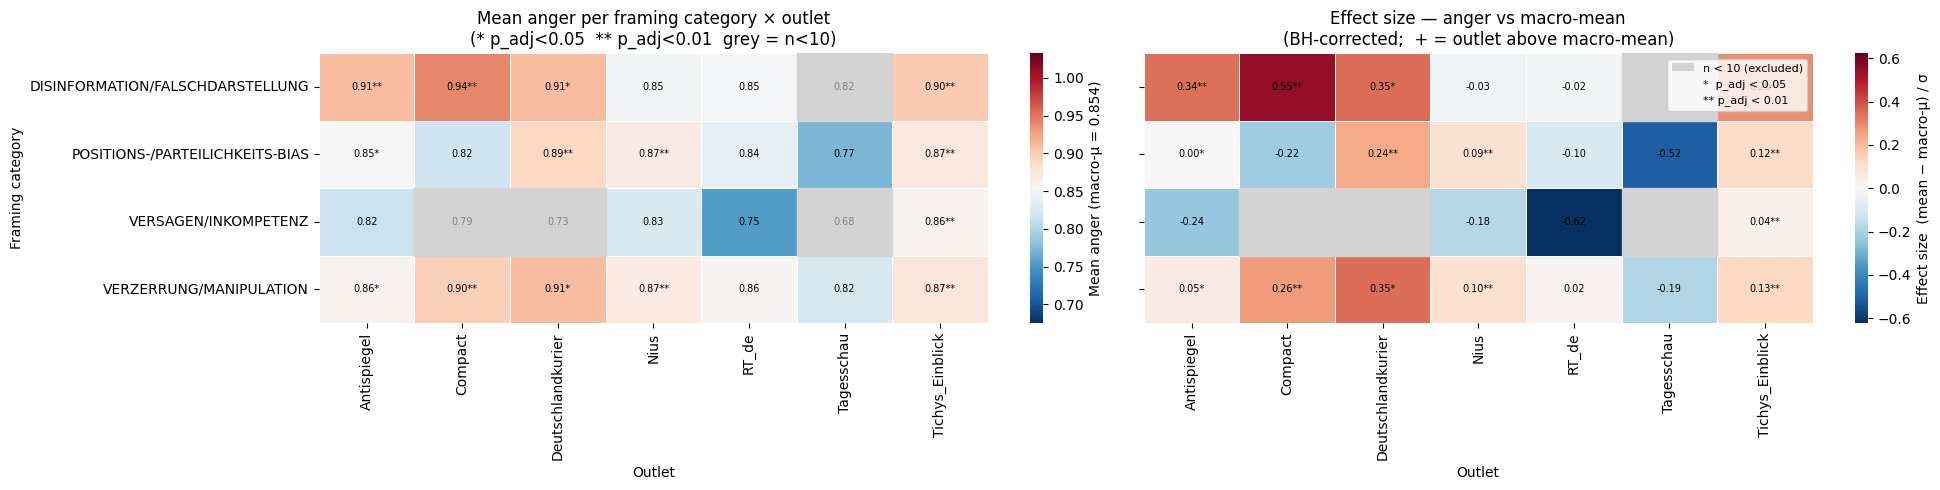

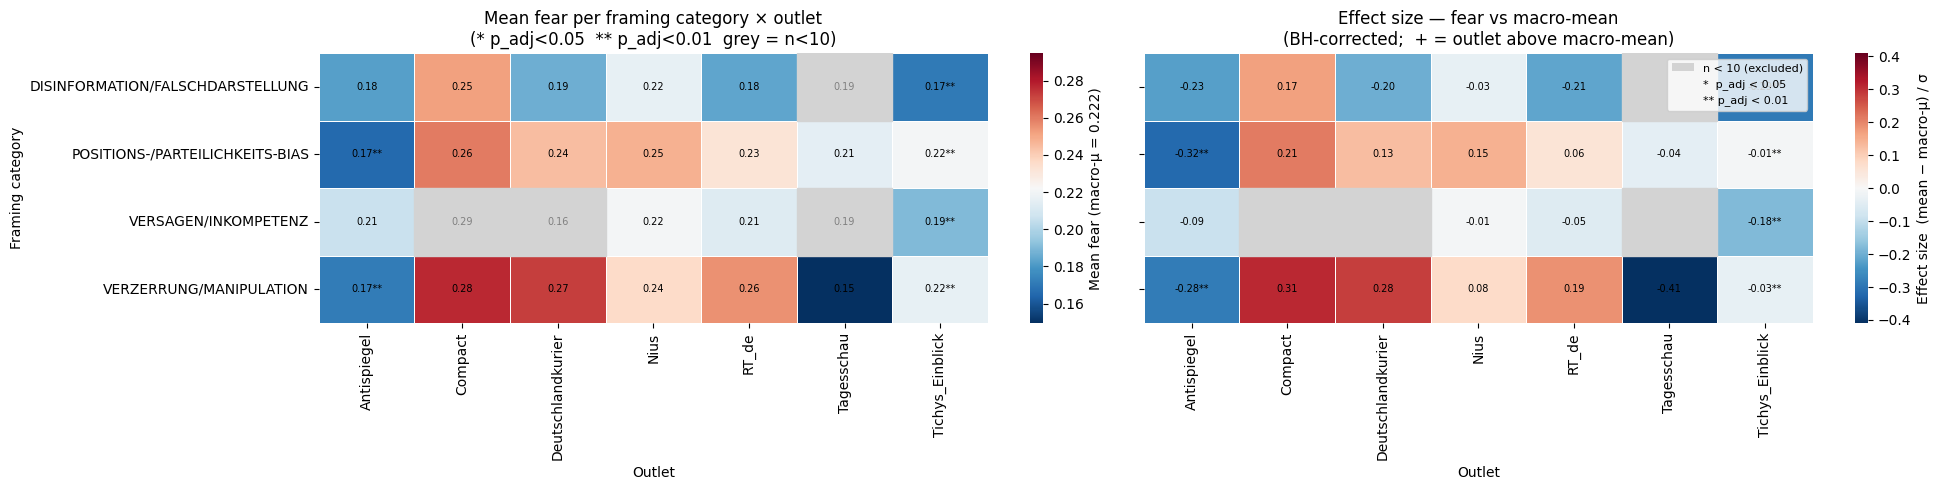

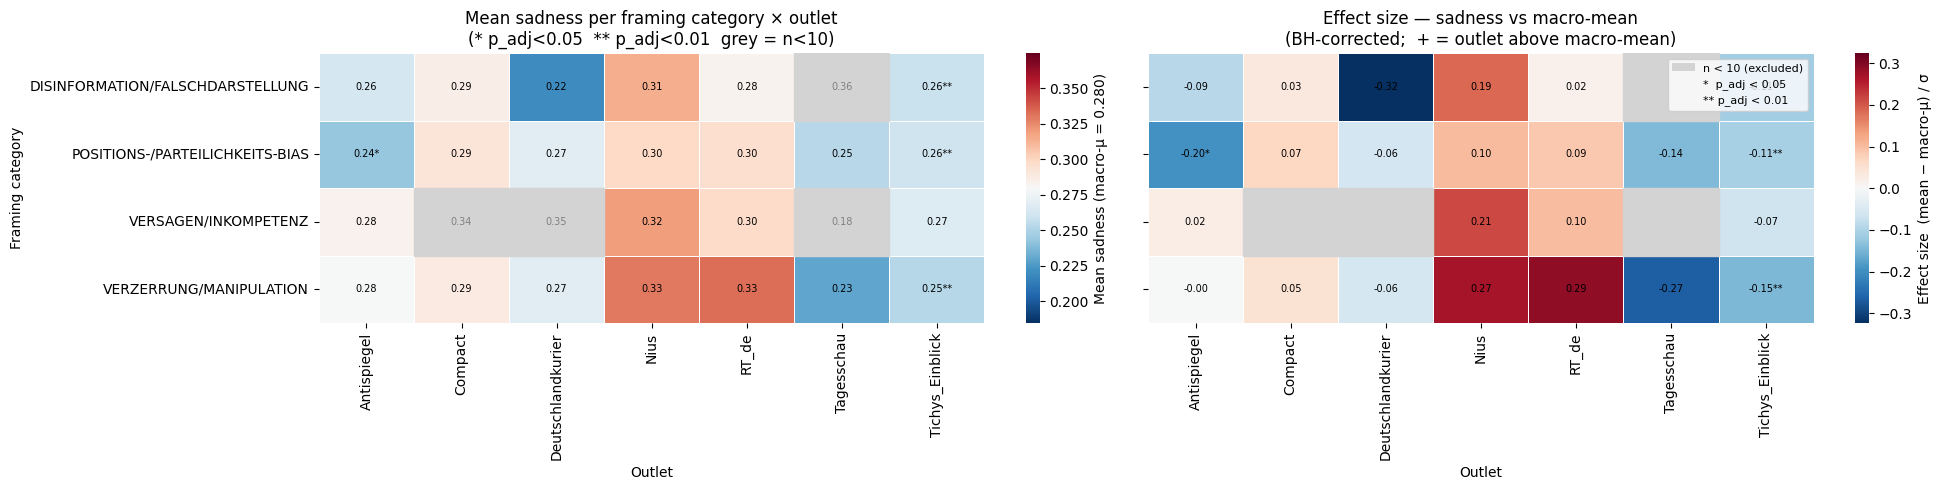

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

def sig_marker(p):
    if p < 0.01: return "**"
    if p < 0.05: return "*"
    return ""

all_outlets = sorted(df["source"].unique())
categories  = sorted(df["category"].unique())

for emotion in EMOTIONS:
    em_label = emotion.replace("emotion_", "")
    mm       = macro_mean[emotion]
    sub_res  = results[results["emotion"] == emotion].set_index(["category", "outlet"])

    # ── pivot: mean score ──────────────────────────────────────────────────────
    mean_piv = (
        df.groupby(["category", "source"])[emotion].mean()
        .unstack("source")
        .reindex(index=categories, columns=all_outlets)
    )
    n_piv = (
        df.groupby(["category", "source"])[emotion].count()
        .unstack("source")
        .reindex(index=categories, columns=all_outlets)
        .fillna(0)
    )
    grey_mask = n_piv < MIN_N

    vals   = mean_piv.to_numpy(dtype=float)
    spread = max(float(np.nanmax(np.abs(vals - mm))), 1e-6)
    vmin, vmax = mm - spread, mm + spread

    # ── pivot: standardised effect size ───────────────────────────────────────
    effect_piv = (
        sub_res["effect"].unstack("outlet")
        .reindex(index=categories, columns=all_outlets)
    )
    e_arr    = effect_piv.to_numpy(dtype=float)
    e_spread = max(float(np.nanmax(np.abs(e_arr[~np.isnan(e_arr)]))), 1e-6) if not np.all(np.isnan(e_arr)) else 1e-6

    fig, (ax1, ax2) = plt.subplots(1, 2,
        figsize=(max(20, 1.5 * len(all_outlets)),
                 max(5,  0.5  * len(categories))))

    # Heatmap 1: mean score
    sns.heatmap(mean_piv, ax=ax1, annot=False, cmap="RdBu_r",
                center=mm, vmin=vmin, vmax=vmax,
                linewidths=0.4, linecolor="white",
                cbar_kws={"label": f"Mean {em_label} (macro-μ = {mm:.3f})"})
    for ri, cat in enumerate(categories):
        for ci, outlet in enumerate(all_outlets):
            val    = mean_piv.at[cat, outlet]
            marker = sig_marker(sub_res.loc[(cat, outlet), "p_adjusted"]) \
                     if (cat, outlet) in sub_res.index else ""
            if grey_mask.at[cat, outlet]:
                ax1.add_patch(plt.Rectangle((ci, ri), 1, 1, color="lightgrey", zorder=2))
                if not np.isnan(val):
                    ax1.text(ci+.5, ri+.5, f"{val:.2f}", ha="center", va="center",
                             fontsize=7, color="grey", zorder=3)
            else:
                ax1.text(ci+.5, ri+.5,
                         f"{val:.2f}{marker}" if not np.isnan(val) else "",
                         ha="center", va="center", fontsize=7, color="black", zorder=3)

    ax1.set_title(f"Mean {em_label} per framing category × outlet\n(* p_adj<0.05  ** p_adj<0.01  grey = n<{MIN_N})")
    ax1.set_xlabel("Outlet"); ax1.set_ylabel("Framing category")

    # Heatmap 2: standardised effect size (mean − macro-mean) / σ
    sns.heatmap(effect_piv, ax=ax2, annot=False, cmap="RdBu_r",
                center=0, vmin=-e_spread, vmax=e_spread,
                linewidths=0.4, linecolor="white",
                cbar_kws={"label": "Effect size  (mean − macro-μ) / σ"})
    for ri, cat in enumerate(categories):
        for ci, outlet in enumerate(all_outlets):
            val    = effect_piv.at[cat, outlet] if cat in effect_piv.index else float("nan")
            marker = sig_marker(sub_res.loc[(cat, outlet), "p_adjusted"]) \
                     if (cat, outlet) in sub_res.index else ""
            grey   = (cat, outlet) not in sub_res.index
            if grey:
                ax2.add_patch(plt.Rectangle((ci, ri), 1, 1, color="lightgrey", zorder=2))
                if not np.isnan(val):
                    ax2.text(ci+.5, ri+.5, f"{val:.2f}", ha="center", va="center",
                             fontsize=7, color="grey", zorder=3)
            else:
                ax2.text(ci+.5, ri+.5,
                         f"{val:.2f}{marker}" if not np.isnan(val) else "",
                         ha="center", va="center", fontsize=7, color="black", zorder=3)

    legend = [mpatches.Patch(facecolor="lightgrey", label=f"n < {MIN_N} (excluded)"),
              plt.Line2D([0],[0], color="none", label="*  p_adj < 0.05"),
              plt.Line2D([0],[0], color="none", label="** p_adj < 0.01")]
    ax2.legend(handles=legend, loc="upper right", fontsize=8, frameon=True)
    ax2.set_title(f"Effect size — {em_label} vs macro-mean\n(BH-corrected;  + = outlet above macro-mean)")
    ax2.set_xlabel("Outlet"); ax2.set_ylabel("")
    ax2.set_yticklabels([])

    plt.tight_layout()
    plt.show()
